# R-402 methanol reactor rate-based design using VBF kinetics


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp

from html import escape
try:
    from IPython.display import display, HTML
    def _display_html(markup, fallback): display(HTML(markup))
except ImportError:
    def _display_html(markup, fallback): print(fallback)

def display_table(df, title=None, formats=None):
    formats = formats or {}
    shown = df.copy()
    for col in shown.columns:
        def fmt(value):
            if pd.isna(value): return '—'
            if col in formats: return formats[col].format(value)
            if isinstance(value,(float,np.floating)):
                return f'{value:.3e}' if 0 < abs(value) < 0.001 else f'{value:,.3f}'
            return str(value)
        shown[col] = shown[col].map(fmt)
    style = '<style>.r402{font:14px/1.5 system-ui,sans-serif;margin:12px 0 20px;overflow-x:auto}.r402 table{border-collapse:collapse;min-width:460px;max-width:100%}.r402 th{background:#203d52;color:white;text-align:left;padding:9px 14px}.r402 td{padding:7px 14px;border-bottom:1px solid #dce3e8;text-align:right;white-space:nowrap}.r402 td:first-child,.r402 td:last-child{text-align:left;white-space:normal}.r402 tr:nth-child(even){background:#f3f6f8}.r402 caption{text-align:left;font-weight:650;font-size:16px;padding:0 0 8px;color:#203d52}</style>'
    caption = '<caption>'+escape(title)+'</caption>' if title else ''
    headers = ''.join('<th>'+escape(str(v))+'</th>' for v in shown.columns)
    rows = ''.join('<tr>'+''.join('<td>'+escape(str(v))+'</td>' for v in row)+'</tr>' for row in shown.itertuples(index=False,name=None))
    markup=style+'<div class="r402"><table>'+caption+'<thead><tr>'+headers+'</tr></thead><tbody>'+rows+'</tbody></table></div>'
    _display_html(markup,(title+'\n' if title else '')+shown.to_string(index=False))

def metric_table(title, rows):
    display_table(pd.DataFrame(rows,columns=['Quantity','Value']),title)


## 1. Inputs and assumptions


In [4]:
# ------------------------------------------------------------
# 1.1 Species
# ------------------------------------------------------------
species = [
    "H2", "CO", "CO2", "CH4", "N2",
    "H2O", "CH3OH", "C2H2", "C2H4", "C2H6", "C6H6"
]

reactive_species = ["H2", "CO", "CO2", "H2O", "CH3OH"]

# ------------------------------------------------------------
# 1.2 Stream 405 inlet mass flows [kg/h]
# ------------------------------------------------------------
mass_flow_kg_h = {
    "H2": 3783.344,
    "CO": 15809.452,
    "CO2": 4703.471,
    "CH4": 7887.074,
    "N2": 455.726,
    "H2O": 1.265,
    "CH3OH": 423.206,
    "C2H2": 78.953,
    "C2H4": 1316.273,
    "C2H6": 5.568,
    "C6H6": 0.509,
}

T_in_C = 250.0
P_in_bar = 48.96

# ------------------------------------------------------------
# 1.3 Initial reactor geometry and hydraulic design basis
# ------------------------------------------------------------
tube_ID = 0.040                 # m
tube_OD = 0.044                 # m
target_superficial_velocity = 0.40  # m/s at reactor inlet; used to calculate tube count

max_bed_length = 20.0            # m; numerical upper bound for the length search

catalyst_particle_diameter = 0.005   # m
catalyst_particle_density = 1775.0   # kgcat/m3 particle
bed_voidage = 0.50
catalyst_bulk_density = catalyst_particle_density*(1-bed_voidage) # kgcat/m3 packed bed

tube_pitch_ratio = 1.25

# ------------------------------------------------------------
# 1.4 Heat removal
# ------------------------------------------------------------
coolant_temperature_C = 240.0


# ------------------------------------------------------------
# 1.5 Gas / catalyst transport inputs
# ------------------------------------------------------------
gas_viscosity = 2.50e-5        

# Lommerts catalyst transport
epsilon_over_tortuosity = 0.123
mean_pore_radius = 10.0e-9      # m

# Fuller diffusion volumes [cm3/mol]
# Simple-molecule values and group-contribution values.
diffusion_volume = {
    "H2": 7.07,
    "CO": 18.9,
    "CO2": 26.9,
    "H2O": 12.7,
    "CH3OH": 29.9,
    "CH4": 24.42,
    "N2": 17.9,
    "C2H2": 36.96,
    "C2H4": 40.92,
    "C2H6": 44.88,
    "C6H6": 90.68,
}

# ------------------------------------------------------------
# 1.7 Molecular weights [kg/kmol]
# ------------------------------------------------------------
MW = {
    "H2": 2.01588,
    "CO": 28.0101,
    "CO2": 44.0095,
    "CH4": 16.0425,
    "N2": 28.0134,
    "H2O": 18.01528,
    "CH3OH": 32.04186,
    "C2H2": 26.0373,
    "C2H4": 28.0532,
    "C2H6": 30.0690,
    "C6H6": 78.1118,
}

# ------------------------------------------------------------
# 1.8 RKS-BM pure-component inputs
# Tc [K], Pc [bar], acentric factor [-]
# ------------------------------------------------------------
Tc = {
    "H2": 33.145, "CO": 132.86, "CO2": 304.1282,
    "CH4": 190.564, "N2": 126.192, "H2O": 647.096,
    "CH3OH": 512.60, "C2H2": 308.30, "C2H4": 282.35,
    "C2H6": 305.32, "C6H6": 562.02,
}

Pc_bar = {
    "H2": 12.964, "CO": 34.94, "CO2": 73.773,
    "CH4": 45.99, "N2": 33.958, "H2O": 220.64,
    "CH3OH": 80.90, "C2H2": 61.40, "C2H4": 50.41,
    "C2H6": 48.72, "C6H6": 48.94,
}

omega = {
    "H2": -0.219, "CO": 0.0497, "CO2": 0.22394,
    "CH4": 0.01142, "N2": 0.0372, "H2O": 0.3443,
    "CH3OH": 0.565, "C2H2": 0.187, "C2H4": 0.0865,
    "C2H6": 0.0995, "C6H6": 0.2103,
}

kij_user = {
    ("CO", "CO2"): 0.1164,
    ("CO", "H2"): -7.0e-4,
    ("CO", "H2O"): -0.5594,
    ("CO", "CH4"): 2.04e-2,
    ("CO", "N2"): 1.30e-2,
    ("CO", "CH3OH"): 0.0,

    ("CO2", "H2"): 0.1164,
    ("CO2", "H2O"): -0.12155,
    ("CO2", "CH4"): 9.56e-2,
    ("CO2", "N2"): -1.71e-2,
    ("CO2", "CH3OH"): 1.70e-2,

    ("H2", "H2O"): -0.7544,
    ("H2", "CH4"): 1.00e-4,
    ("H2", "N2"): -1.00e-3,
    ("H2", "CH3OH"): 0.0,

    ("H2O", "CH4"): 0.5,
    ("H2O", "N2"): -0.69648,
    ("H2O", "CH3OH"): -9.00e-2,

    ("CH4", "N2"): 3.12e-2,
    ("CH4", "CH3OH"): -3.50e-2,

    ("N2", "CH3OH"): -0.2141,
}

# ------------------------------------------------------------
# 1.9 gas heat capacities [J/mol/K]
# ------------------------------------------------------------
Cp_ref = {
    "H2": 29.3, "CO": 30.5, "CO2": 44.5,
    "CH4": 48.0, "N2": 30.0, "H2O": 35.5,
    "CH3OH": 55.0, "C2H2": 55.0, "C2H4": 65.0,
    "C2H6": 75.0, "C6H6": 105.0,
}

# ------------------------------------------------------------
# 1.10 Reaction enthalpies at 298.15 K [J/mol reaction]
# R1: CO2 + 3H2 -> CH3OH + H2O
# R2: CO2 + H2  -> CO + H2O
# R3: CO + 2H2  -> CH3OH
# ------------------------------------------------------------
deltaH_298 = np.array([
    -49.5e3,
    +41.2e3,
])

# ------------------------------------------------------------
# 1.11 Vanden Bussche-Froment parameters (1996, Table 2)
# A*exp(B/(R*T)); T in K and R in J/mol/K. Input partial pressures in bar.
# kM: mol/(kgcat s bar^2); kR: mol/(kgcat s bar).
VBF_kM_A, VBF_kM_B = 1.07, 36696.0
VBF_kR_A, VBF_kR_B = 1.22e10, -94765.0
VBF_ads_H_A, VBF_ads_H_B = 0.499, 17197.0  # bar^-0.5
VBF_ads_W_A, VBF_ads_W_B = 6.62e-11, 124119.0  # bar^-1
VBF_water_ratio = 3453.38  # dimensionless

VBF_T_min_C, VBF_T_max_C = 180.0, 280.0
VBF_P_min_bar, VBF_P_max_bar = 15.0, 51.0

# ------------------------------------------------------------
# 1.13 Numerical reactor settings
# ------------------------------------------------------------
profile_points = 301

R = 8.314462618
R_EOS = 0.08314462618

heat_transfer_mode = 'provisional_U'  # or 'resistances'
provisional_Uo = 280.0  # W/m2/K, outside area; NOT a calculated coefficient
h_bed_inner = None     # W/m2/K, effective packed-bed-to-inner-wall coefficient
h_boiling_outer = None # W/m2/K, boiling-water-side coefficient
wall_conductivity = None # W/m/K, from selected tube material at operating temperature
Rf_inner = 0.0         # m2 K/W, clean-surface assumption, replace when specified
Rf_outer = 0.0
# Scalars or callables h(T, P_bar, y, u_s) may be supplied for either side.
knudsen_radius_factor = 4.0/3.0 # Retains Lommerts et al. (2000), Eq. 27 convention.
# Conventional straight cylindrical pore model uses 2/3.
permeability = epsilon_over_tortuosity*mean_pore_radius**2/8 # m2, capillary estimate
pellet_tol = 2e-5
pellet_max_nodes = 500
pellet_mesh_n = 24
axial_rtol = 2e-5
axial_max_step = 0.12
axial_method = 'RK45'
reactor_dP_limit_bar = 0.50  # bar; conservative R-402 design limit
required_net_MeOH_kg_h = 9000.0 # kg/h NET methanol formed in R-402; rate-based sizing target.
hotspot_limit_C = 285.0
film_rate_change_limit = 0.05 # Engineering screening tolerance; not a kinetic validation.
RUN_GRID_CHECK = True

# Numerical acceptance settings; these do not change physical design inputs.
pellet_negative_c_tol = 1e-12 # Allowed roundoff in c_i = C_i/C_total_bulk, independent of BVP tolerance
bed_length_grid_rtol = 1e-4   # Relative convergence tolerance on calculated bed length
bed_length_grid_atol = 1e-5   # m; absolute convergence tolerance on calculated bed length


In [5]:
assert 0 < bed_voidage < 1 and 0 < epsilon_over_tortuosity <= 1
assert 0 < tube_ID < tube_OD and max_bed_length > 0
assert target_superficial_velocity > 0
assert catalyst_particle_density > 0 and catalyst_particle_diameter > 0
assert gas_viscosity > 0 and mean_pore_radius > 0
assert set(mass_flow_kg_h) == set(species)
assert all(mass_flow_kg_h[s] >= 0 and MW[s] > 0 and Cp_ref[s] > 0 for s in species)
assert all(diffusion_volume[s] > 0 and Tc[s] > 0 and Pc_bar[s] > 0 for s in species)
display_table(pd.DataFrame([
 ['Inlet temperature',T_in_C,'°C'],['Inlet pressure',P_in_bar,'bar'],
 ['Target inlet superficial velocity',target_superficial_velocity,'m/s'],['Tube inside diameter',tube_ID*1000,'mm'],
 ['Tube outside diameter',tube_OD*1000,'mm'],['Net methanol production target',required_net_MeOH_kg_h,'kg/h'],
 ['Maximum bed-length search bound',max_bed_length,'m'],
 ['Pellet diameter',catalyst_particle_diameter*1000,'mm'],
 ['Packed catalyst density',catalyst_bulk_density,'kg/m³'],['Bed void fraction',bed_voidage,'—'],
 ['Gas viscosity (provisional)',gas_viscosity,'Pa·s'],['Coolant temperature',coolant_temperature_C,'°C'],
],columns=['Input','Value','Unit']),'Design inputs')

assert isinstance(profile_points, int) and profile_points >= 3
assert T_in_C > -273.15 and coolant_temperature_C > -273.15 and P_in_bar > 0
assert pellet_tol > 0 and axial_rtol > 0 and axial_max_step > 0
assert pellet_mesh_n >= 3 and pellet_max_nodes >= pellet_mesh_n
assert pellet_negative_c_tol >= 0 and bed_length_grid_atol > 0 and bed_length_grid_rtol > 0
assert required_net_MeOH_kg_h > 0


Input,Value,Unit
Inlet temperature,250.000,°C
Inlet pressure,48.960,bar
Target inlet superficial velocity,0.400,m/s
Tube inside diameter,40.000,mm
Tube outside diameter,44.000,mm
Net methanol production target,"9,000.000",kg/h
Maximum bed-length search bound,20.000,m
Pellet diameter,5.000,mm
Packed catalyst density,887.500,kg/m³
Bed void fraction,0.500,—


## 2. Feed and stoichiometry


In [7]:
# ============================================================
# SECTION 2 - FEED AND STOICHIOMETRY
# ============================================================

idx = {s: i for i, s in enumerate(species)}
inert_species = [s for s in species if s not in reactive_species]

MW_vec = np.array([MW[s] for s in species])
MW_vec_kg_mol = MW_vec / 1000.0
Cp_vec = np.array([Cp_ref[s] for s in species])

F0 = np.array([mass_flow_kg_h[s] / MW[s] * 1000.0 / 3600.0 for s in species])

T_in = T_in_C + 273.15
P_in_Pa = P_in_bar * 1.0e5
T_coolant = coolant_temperature_C + 273.15

nu = np.zeros((len(species), 2))

for s, v in {"CO2": -1, "H2": -3, "CH3OH": 1, "H2O": 1}.items():
    nu[idx[s], 0] = v

for s, v in {"CO2": -1, "H2": -1, "CO": 1, "H2O": 1}.items():
    nu[idx[s], 1] = v


reactive_indices = [idx[s] for s in reactive_species]

feed_table = pd.DataFrame(
    {
        "Component": species,
        "Mass flow (kg/h)": [mass_flow_kg_h[s] for s in species],
        "Molar flow (kmol/h)": [F0[idx[s]] * 3.6 for s in species],
        "Mole fraction": F0 / F0.sum(),
    }
)

metric_table(
    "Feed summary",
    [
        ("Total Stream 405 mass flow (kg/h)", f"{sum(mass_flow_kg_h.values()):,.3f}"),
        ("Total Stream 405 molar flow (kmol/h)", f"{F0.sum() * 3.6:,.3f}"),
        ("Inlet temperature (°C)", f"{T_in_C:.2f}"),
        ("Inlet pressure (bar)", f"{P_in_bar:.2f}"),
    ],
)

display_table(
    feed_table,
    title="Stream 405 component feed table",
    formats={
        "Mass flow (kg/h)": "{:,.3f}",
        "Molar flow (kmol/h)": "{:,.3f}",
        "Mole fraction": "{:.6f}",
    },
)


Quantity,Value
Total Stream 405 mass flow (kg/h),"34,464.841"
Total Stream 405 molar flow (kmol/h),"3,119.391"
Inlet temperature (°C),250.00
Inlet pressure (bar),48.96


Component,Mass flow (kg/h),Molar flow (kmol/h),Mole fraction
H2,"3,783.344","1,876.770",0.601646
CO,"15,809.452",564.420,0.180939
CO2,"4,703.471",106.874,0.034261
CH4,"7,887.074",491.636,0.157606
N2,455.726,16.268,0.005215
H2O,1.265,0.070,0.000023
CH3OH,423.206,13.208,0.004234
C2H2,78.953,3.032,0.000972
C2H4,"1,316.273",46.921,0.015042
C2H6,5.568,0.185,0.000059


## 3. RKS-BM equation of state


In [9]:
# ============================================================
# SECTION 3 - RKS-BM EOS
# ============================================================

def build_kij_matrix():
    K = np.zeros((len(species), len(species)))
    for (si, sj), value in kij_user.items():
        i, j = idx[si], idx[sj]
        K[i, j] = value
        K[j, i] = value
    return K

kij = build_kij_matrix()

def alpha_boston_mathias(T, component):
    Tr = T / Tc[component]
    w = omega[component]

    m = 0.48508 + 1.55171*w - 0.15613*w*w

    if Tr <= 1.0:
        return (1.0 + m*(1.0 - math.sqrt(Tr)))**2

    d = 1.0 + m/2.0
    c = 1.0 - 1.0/d
    return math.exp(c*(1.0 - Tr**d))**2


def rks_bm(T, P_bar, y):
    ai = np.array([
        0.42747 * R_EOS**2 * Tc[s]**2 / Pc_bar[s]
        * alpha_boston_mathias(T, s)
        for s in species
    ])

    bi = np.array([
        0.08664 * R_EOS * Tc[s] / Pc_bar[s]
        for s in species
    ])

    aij = np.sqrt(np.outer(ai, ai)) * (1.0 - kij)

    a_mix = float(y @ aij @ y)
    b_mix = float(y @ bi)

    A = a_mix * P_bar / (R_EOS**2 * T**2)
    B = b_mix * P_bar / (R_EOS * T)

    roots = np.roots([
        1.0,
        -1.0,
        A - B - B**2,
        -A*B,
    ])

    real_roots = [
        r.real for r in roots
        if abs(r.imag) < 1.0e-8
    ]

    if not real_roots:
        raise RuntimeError("No real RKS-BM root.")

    Z = max(real_roots)

    sum_y_aij = aij @ y

    ln_phi = (
        (bi/b_mix)*(Z - 1.0)
        - np.log(Z - B)
        - (A/B)
        * (
            2.0*sum_y_aij/a_mix
            - bi/b_mix
        )
        * np.log(1.0 + B/Z)
    )

    phi = np.exp(ln_phi)
    f_bar = phi * y * P_bar

    return Z, phi, f_bar


y0 = F0/F0.sum()
Z0, phi0, f0 = rks_bm(T_in, P_in_bar, y0)

# ------------------------------------------------------------
# Reactor tube count from selected inlet superficial velocity
# ------------------------------------------------------------
# The target velocity is imposed only at the reactor inlet.
# Local superficial velocity is recalculated along the bed as
# total molar flow, temperature, pressure and Z change.
A_tube_sizing = math.pi * tube_ID**2 / 4.0
inlet_volumetric_flow = F0.sum() * Z0 * R * T_in / P_in_Pa
number_of_tubes = math.ceil(
    inlet_volumetric_flow / (target_superficial_velocity * A_tube_sizing)
)
actual_inlet_superficial_velocity = (
    inlet_volumetric_flow / (number_of_tubes * A_tube_sizing)
)
total_inlet_flow_area = number_of_tubes * A_tube_sizing



eos_check = pd.DataFrame(
    {
        "Component": species,
        "y_i": y0,
        "phi_i": phi0,
        "f_i (bar)": f0,
    }
)

metric_table(
    "RKS-BM inlet thermodynamic summary",
    [
        ("Inlet compressibility factor, Z", f"{Z0:.5f}"),
        ("Property method", "RKS-BM"),
        ("Gas-phase root selected", "Largest real root"),
    ],
)

display_table(
    eos_check,
    title="Inlet fugacity-coefficient check",
    formats={"y_i": "{:.6f}", "phi_i": "{:.5f}", "f_i (bar)": "{:.5f}"},
)

metric_table(
    "Reactor hydraulic sizing basis",
    [
        ("Selected inlet superficial velocity (m/s)", f"{target_superficial_velocity:.3f}"),
        ("Inlet volumetric flow (m³/s)", f"{inlet_volumetric_flow:.4f}"),
        ("Single-tube flow area (m²)", f"{A_tube_sizing:.6e}"),
        ("Calculated number of tubes", f"{number_of_tubes:d}"),
        ("Actual inlet superficial velocity (m/s)", f"{actual_inlet_superficial_velocity:.4f}"),
        ("Total inlet flow area (m²)", f"{total_inlet_flow_area:.4f}"),
    ],
)


Quantity,Value
"Inlet compressibility factor, Z",1.02175
Property method,RKS-BM
Gas-phase root selected,Largest real root


Component,y_i,phi_i,f_i (bar)
H2,0.601646,1.02183,30.09957
CO,0.180939,1.02675,9.09576
CO2,0.034261,1.01209,1.69770
CH4,0.157606,1.01956,7.86735
N2,0.005215,1.02652,0.26211
H2O,0.000023,0.96904,0.00107
CH3OH,0.004234,0.99307,0.20587
C2H2,0.000972,1.01287,0.04821
C2H4,0.015042,1.01709,0.74902
C2H6,0.000059,1.01770,0.00296


Quantity,Value
Selected inlet superficial velocity (m/s),0.400
Inlet volumetric flow (m³/s),0.7866
Single-tube flow area (m²),1.256637e-03
Calculated number of tubes,1565
Actual inlet superficial velocity (m/s),0.4000
Total inlet flow area (m²),1.9666


# 4. VBF equilibrium expressions


In [11]:
# Original VBF equilibrium expressions, T [K], partial pressures [bar].
# KM = pMeOH*pH2O/(pCO2*pH2^3); KR = pCO*pH2O/(pCO2*pH2).
def equilibrium_constants(T):
    KM=10.0**(3066.0/T-10.592)
    KR=10.0**(-2073.0/T+2.029)
    return KM,KR

display_table(pd.DataFrame([
 ['Methanol equilibrium constant',equilibrium_constants(T_in)[0],'bar^-2'],
 ['RWGS equilibrium constant',equilibrium_constants(T_in)[1],'—'],
],columns=['Quantity','Value','Unit']),'Equilibrium at the inlet temperature',{'Value':'{:.6e}'})


Quantity,Value,Unit
Methanol equilibrium constant,1.856316e-05,bar^-2
RWGS equilibrium constant,1.165374e-02,—


# 5. Vanden Bussche Froment kinetics


In [13]:
# Vanden Bussche & Froment (1996), Eq. 3 and Table 2.
# https://user.eng.umd.edu/~nsw/chbe446/VandenBussche-syngas2MeOH.pdf
# Published partial-pressure formulation; mol/kgcat/s. No fitted activity multiplier.
def vbf_parameters(T):
    return (VBF_kM_A*np.exp(VBF_kM_B/(R*T)),
            VBF_kR_A*np.exp(VBF_kR_B/(R*T)),
            VBF_ads_H_A*np.exp(VBF_ads_H_B/(R*T)),
            VBF_ads_W_A*np.exp(VBF_ads_W_B/(R*T)))

def vbf_directional_rates(T,p_bar):
    p=np.maximum(np.asarray(p_bar),1e-30)
    H=p[idx['H2']]; C=p[idx['CO']]; D=p[idx['CO2']]
    W=p[idx['H2O']]; M=p[idx['CH3OH']]
    kM,kR,adsH,adsW=vbf_parameters(T)
    KM,KR=equilibrium_constants(T)
    den=1+VBF_water_ratio*W/H+adsH*np.sqrt(H)+adsW*W
    forward=np.array([kM*D*H/den**3,kR*D/den])
    reverse=np.array([kM*M*W/(KM*H**2*den**3),kR*W*C/(KR*H*den)])
    return np.array([forward,reverse])

def vbf_rates(T,P_bar,y):
    # EOS still supplies Z, density and diagnostic fugacity coefficients.
    Z,phi,f_bar=rks_bm(T,P_bar,y)
    r=vbf_directional_rates(T,np.asarray(y)*P_bar)
    return r[0]-r[1],Z,phi,f_bar

display_table(pd.DataFrame({'Reaction':['CO2 hydrogenation','Reverse water–gas shift'],
 'Intrinsic rate (mol/kgcat/s)':vbf_rates(T_in,P_in_bar,y0)[0]}),'Inlet intrinsic rates',
 {'Intrinsic rate (mol/kgcat/s)':'{:.6e}'})


Reaction,Intrinsic rate (mol/kgcat/s)
CO2 hydrogenation,8.429412e-02
Reverse water–gas shift,4.876313e-02


## 6. Molecular and pore diffusion


In [15]:
# ============================================================
# SECTION 6 - PORE DIFFUSION
# ============================================================

def fuller_binary_diffusivity(T, P_bar, i, j):
    """
    Fuller-Schettler-Giddings binary diffusivity [m2/s].
    T [K], P [bar].
    """
    

    D_cm2_s = (
        0.00143
        * T**1.75
        * math.sqrt((1.0/MW[i] + 1.0/MW[j])/2.0)
        / (
            P_bar
            * (
                diffusion_volume[i]**(1.0/3.0)
                + diffusion_volume[j]**(1.0/3.0)
            )**2
        )
    )

    return D_cm2_s*1.0e-4


def mixture_diffusivity(T, P_bar, y, i):
    denom = 0.0

    for j in species:
        if j == i:
            continue

        denom += (
            y[idx[j]]
            / fuller_binary_diffusivity(T, P_bar, i, j)
        )

    return (
        (1.0 - y[idx[i]])
        / denom
    )


def knudsen_diffusivity(T, i):
    M_kg_mol = MW[i]/1000.0

    return (
        knudsen_radius_factor
        * mean_pore_radius
        * math.sqrt(
            8.0*R*T/(math.pi*M_kg_mol)
        )
    )


def effective_diffusivity(T, P_bar, y, i):
    D_m = mixture_diffusivity(T, P_bar, y, i)
    D_K = knudsen_diffusivity(T, i)

    D_pore = 1.0/(1.0/D_m + 1.0/D_K)

    return epsilon_over_tortuosity*D_pore


# Scalar Bosanquet estimates are diagnostics only. The pellet BVP uses
# separate Knudsen coefficients and the full binary-diffusivity matrix.
diff_check = pd.DataFrame({
    "Species": reactive_species,
    "D_eff at inlet (m2/s)": [
        effective_diffusivity(T_in, P_in_bar, y0, s)
        for s in reactive_species
    ],
})



display_table(
    diff_check,
    title="Diagnostic scalar diffusivities at the inlet (not the full pellet transport model)",
    formats={"D_eff at inlet (m2/s)": "{:.4e}"},
)

Species,D_eff at inlet (m2/s)
H2,4.2281e-07
CO,2.2752e-07
CO2,1.6686e-07
H2O,2.4394e-07
CH3OH,1.6720e-07


## 7. Thermochemistry


In [17]:
# Component Cp is constant. Mixture Cp varies with composition. Residual enthalpies are omitted.
# ============================================================
# SECTION 8 - THERMOCHEMISTRY
# ============================================================

deltaCp_reaction = nu.T @ Cp_vec

def reaction_enthalpies(T):
    return (
        deltaH_298
        + deltaCp_reaction*(T - 298.15)
    )

def heat_capacity_flow(F):
    return float(np.dot(F, Cp_vec))

display_table(pd.DataFrame({'Reaction':['CO2 hydrogenation','Reverse water–gas shift'],
 'At 298.15 K (kJ/mol)':deltaH_298/1000,'At inlet (kJ/mol)':reaction_enthalpies(T_in)/1000}),
 'Reaction enthalpies')


Reaction,At 298.15 K (kJ/mol),At inlet (kJ/mol)
CO2 hydrogenation,-49.500,-58.928
Reverse water–gas shift,41.200,39.445


## 8. Heat removal and coupled pellet calculation


In [19]:
# Uo uses outside area. hi must describe the packed bed; ho must describe boiling water.
# Empty-tube and single-phase shell correlations do not establish these coefficients.
# number_of_tubes was calculated from the selected inlet superficial velocity in Section 3.
A_tube = math.pi*tube_ID**2/4
catalyst_mass_per_length = number_of_tubes*A_tube*catalyst_bulk_density


def local_hydraulics(F,T,P_Pa):
    if P_Pa <= 0 or T <= 0 or F.sum() <= 0:
        raise ValueError('Non-positive pressure, temperature or total flow.')
    y=F/F.sum();Z,_,_=rks_bm(T,P_Pa/1e5,y)
    rho=P_Pa*np.dot(y,MW_vec_kg_mol)/(Z*R*T)
    u=F.sum()*Z*R*T/P_Pa/(number_of_tubes*A_tube)
    return Z,rho,u


def U_from_resistances(hi,ho,kw,Rfi=0.0,Rfo=0.0):
    """Uo [W/m2/K], outside area, supplied guidelines p.2.
    hi must describe the packed bed to tube wall, not an empty-tube film.
    Rfi and Rfo are fouling RESISTANCES, reciprocal of the guide's dirt coefficients.
    """
    if min(hi,ho,kw)<=0 or min(Rfi,Rfo)<0:
        raise ValueError('Heat-transfer coefficients and wall conductivity must be positive.')
    resistance=1/ho+Rfo+tube_OD*math.log(tube_OD/tube_ID)/(2*kw)+(tube_OD/tube_ID)*(Rfi+1/hi)
    return 1/resistance


def overall_heat_transfer(F,T,P_Pa):
    if heat_transfer_mode=='provisional_U':
        if provisional_Uo<=0:raise ValueError('provisional_Uo must be positive.')
        return provisional_Uo
    if heat_transfer_mode!='resistances':raise ValueError('Unknown heat_transfer_mode.')
    if any(v is None for v in [h_bed_inner,h_boiling_outer,wall_conductivity]):
        raise ValueError('Provide h_bed_inner, h_boiling_outer and wall_conductivity for calculated Uo.')
    y=F/F.sum();_,_,u=local_hydraulics(F,T,P_Pa)
    def value(v):return float(v(T,P_Pa/1e5,y,u)) if callable(v) else float(v)
    return U_from_resistances(value(h_bed_inner),value(h_boiling_outer),value(wall_conductivity),Rf_inner,Rf_outer)


pellet_calls=0


def pellet_rates(T,P_bar,y_bulk,tolerance=None,mesh_n=None):
    """Isothermal spherical pellet, multicomponent dusty-gas transport.
    All 11 concentrations are solved; five reactive fluxes are unknown.
    Inert fluxes are zero, but inert concentrations may vary. Pressure changes
    inside the pellet follow the summed dusty-gas equations, including a
    capillary-estimated Darcy term. Bulk Z is frozen
    inside each pellet (local axial values). Binary diffusivities also use bulk
    pressure within that pellet, so this remains an approximation.

    State c_i=C_i/C_total_bulk; j_i=N_i*Rp/(Dref*C_total_bulk).
    x=r/Rp. N is outward molar flux. Spherical singular terms are supplied to
    solve_bvp through its S matrix, giving zero centre flux exactly at x=0.
    """
    global pellet_calls
    pellet_calls+=1
    ns=len(species);nr=len(reactive_indices);Rp=catalyst_particle_diameter/2
    Z,phi,_=rks_bm(T,P_bar,y_bulk);Ctot=P_bar*1e5/(Z*R*T)
    DK=np.array([knudsen_radius_factor*mean_pore_radius*np.sqrt(8*R*T/(np.pi*MW_vec_kg_mol[i])) for i in range(ns)])*epsilon_over_tortuosity
    Dbin=np.zeros((ns,ns))
    for i in range(ns):
        for j in range(i):
            d=epsilon_over_tortuosity*fuller_binary_diffusivity(T,P_bar,species[i],species[j])
            Dbin[i,j]=Dbin[j,i]=d
    invD=np.divide(1,Dbin,out=np.zeros_like(Dbin),where=Dbin>0)
    Dref=1e-7
    S=np.zeros((ns+nr,ns+nr));S[ns:,ns:]=-2*np.eye(nr)
    x=np.linspace(0,1,mesh_n or pellet_mesh_n)
    guess=np.vstack([np.tile(y_bulk[:,None],(1,len(x))),np.zeros((nr,len(x)))])
    source_scale=1.0
    def rhs(x,st):
        # Positivity floor protects Newton trial iterates only. The converged
        # concentration polynomial is checked before any rate is accepted.
        c=st[:ns];positive=np.maximum(c,1e-25);ct=positive.sum(axis=0)
        y=positive/ct
        # At fixed bulk Z: p_i = c_i*P_bulk. No concentration renormalisation in kinetics.
        f=positive*P_bar  # Local partial pressures for published VBF kinetics.
        directional=vbf_directional_rates(T,f);r=directional[0]-directional[1]
        J=np.zeros_like(c);J[reactive_indices]=st[ns:]
        cross=J*(invD@y)-y*(invD@J)
        g=J/DK[:,None]+cross
        # Summed dusty-gas balance determines total concentration/pressure gradient.
        localP=P_bar*1e5*ct
        b=permeability*localP/gas_viscosity
        dct=-Dref*np.sum(J/DK[:,None],axis=0)/(1+b*np.sum(y/DK[:,None],axis=0))
        dc=-Dref*g-y*b/DK[:,None]*dct
        dj=source_scale*Rp**2*catalyst_particle_density/(Dref*Ctot)*(nu[reactive_indices]@r)
        return np.vstack([dc,dj])
    def bc(a,b):return np.r_[a[ns:],b[:ns]-y_bulk]
    tol=pellet_tol if tolerance is None else tolerance
    sol=solve_bvp(rhs,bc,x,guess,S=S,tol=tol,max_nodes=pellet_max_nodes)
    if not sol.success:
        # Continuation from weaker reaction loading; never suppress a failed solution.
        for source_scale in [0.10,0.35,0.65,1.0]:
            sol=solve_bvp(rhs,bc,x,guess,S=S,tol=tol,max_nodes=pellet_max_nodes)
            if not sol.success:raise RuntimeError('Pellet BVP failed: '+sol.message)
            x=sol.x;guess=sol.y
    gx,gw=np.polynomial.legendre.leggauss(40);xx=(gx+1)/2;ww=gw/2
    st=sol.sol(xx);c=st[:ns]
    # Check all interval endpoints AND interior extrema of the cubic BVP
    # interpolant. Quadrature points alone can miss a negative concentration.
    coeff = sol.sol.c[:, :, :ns] # Cubic coefficients: (power, interval, species)
    minima = float(np.min(sol.y[:ns]))
    if not np.all(np.isfinite(coeff)) or not np.all(np.isfinite(c)):
        raise RuntimeError('Non-finite pellet concentration after convergence.')
    aa, bb, cc = 3*coeff[0], 2*coeff[1], coeff[2]
    disc = bb**2 - 4*aa*cc
    root_disc = np.sqrt(np.maximum(disc, 0))
    candidates = []
    for sign in [-1, 1]:
        roots = np.divide(-bb + sign*root_disc, 2*aa,
                          out=np.full_like(aa, np.nan), where=(aa != 0) & (disc >= 0))
        candidates.append(roots)
    candidates.append(np.divide(-cc, bb, out=np.full_like(bb, np.nan),
                                where=(aa == 0) & (bb != 0)))
    for dx in candidates:
        valid = np.isfinite(dx) & (dx > 0) & (dx < np.diff(sol.x)[:, None])
        dx_safe = np.where(valid, dx, 0.0)
        values = ((coeff[0]*dx_safe + coeff[1])*dx_safe + coeff[2])*dx_safe + coeff[3]
        if np.any(valid): minima = min(minima, float(np.min(values[valid])))
    if minima < -pellet_negative_c_tol:
        raise RuntimeError(f'Negative converged pellet concentration: {minima:.3e}; refine pellet solver.')
    rates=vbf_directional_rates(T,np.maximum(c,0)*P_bar)
    avg=np.sum(rates*(3*ww*xx**2)[None,None,:],axis=2)
    observed=avg[0]-avg[1]
    surf=vbf_directional_rates(T,y_bulk*P_bar)
    flux=np.zeros(ns);flux[reactive_indices]=sol.y[ns:,-1]*Dref*Ctot/Rp
    flux_rate=3*flux/(Rp*catalyst_particle_density)
    balance_error=np.max(np.abs(flux_rate-nu@observed))/max(np.max(np.abs(nu@observed)),1e-12)
    if balance_error>0.002:raise RuntimeError(f'Pellet flux/integrated source disagreement: {balance_error:.3g}')
    raw_ratio=np.divide(observed,surf[0]-surf[1],out=np.full(2,np.nan),where=np.abs(surf[0]-surf[1])>1e-10)
    return {'rates':observed,'forward':avg[0],'reverse':avg[1],'surface_rates':surf[0]-surf[1],
            'net_ratio':raw_ratio,'balance_error':balance_error,'pressure_ratio_min':float(c.sum(axis=0).min()),
            'pressure_ratio_max':float(c.sum(axis=0).max()),'surface_flux':flux,'nodes':sol.x.size,'minimum_scaled_concentration':minima}


def solve_reactor(rtol_override=None,max_step_override=None):
    """Rate-based R-402 sizing.

    The tube count is fixed by the inlet superficial-velocity criterion.
    The coupled material, energy and pressure-drop balances are then integrated
    axially until the specified NET methanol production is reached. The event
    location is therefore the required catalyst-bed length.

    Total cooling is an integrated state (W), so energy closure does not depend
    on plotting-grid quadrature.
    """
    n=len(species)

    def rhs(z,state):
        F=state[:n]
        if np.min(F)<-1e-5:
            raise RuntimeError('Negative component flow encountered; revise design/solver.')
        # Roundoff trial values only; accepted profiles are checked independently.
        F=np.maximum(F,0);T=state[n];P=state[n+1]
        if P<=1e5:
            raise RuntimeError('Reactor pressure fell below 1 bar. No pressure flooring is applied.')
        y=F/F.sum();pellet=pellet_rates(T,P/1e5,y);rr=pellet['rates']
        dF=catalyst_mass_per_length*(nu@rr)
        qr=-catalyst_mass_per_length*np.dot(rr,reaction_enthalpies(T))
        qc=overall_heat_transfer(F,T,P)*number_of_tubes*np.pi*tube_OD*(T-T_coolant)
        dT=(qr-qc)/heat_capacity_flow(F)
        _,rho,u=local_hydraulics(F,T,P)
        e=bed_voidage;dp=catalyst_particle_diameter
        dP=-(150*gas_viscosity*(1-e)**2/(e**3*dp**2)*u
             +1.75*rho*(1-e)/(e**3*dp)*u*u)
        return np.r_[dF,dT,dP,qc]

    def methanol_target_event(z,state):
        F=state[:n]
        net_meoh_kg_h=(F[idx['CH3OH']]-F0[idx['CH3OH']])*MW['CH3OH']*3.6
        return net_meoh_kg_h-required_net_MeOH_kg_h

    methanol_target_event.terminal=True
    methanol_target_event.direction=1

    yinit=np.r_[F0,T_in,P_in_Pa,0.0]
    sol=solve_ivp(
        rhs,(0,max_bed_length),yinit,
        method=axial_method,
        rtol=rtol_override or axial_rtol,
        atol=np.r_[np.full(n,1e-7),1e-4,0.05,0.05],
        max_step=max_step_override or axial_max_step,
        dense_output=True,
        events=methanol_target_event,
    )

    if not sol.success:
        raise RuntimeError(sol.message)
    if np.min(sol.y[:n]) < -1e-7:
        raise RuntimeError('Accepted profile has negative flows.')

    if len(sol.t_events)==0 or sol.t_events[0].size==0:
        F_end=sol.y[:n,-1]
        achieved=(F_end[idx['CH3OH']]-F0[idx['CH3OH']])*MW['CH3OH']*3.6
        raise RuntimeError(
            f'Net methanol target of {required_net_MeOH_kg_h:,.1f} kg/h was not reached '
            f'within the {max_bed_length:.2f} m numerical search bound. '
            f'Achieved {achieved:,.1f} kg/h.'
        )

    sol.bed_length=float(sol.t_events[0][0])
    return sol

inlet_pellet=pellet_rates(T_in,P_in_bar,y0)
display_table(pd.DataFrame({'Reaction':['CO2 hydrogenation','Reverse water–gas shift'],
 'Surface rate (mol/kgcat/s)':inlet_pellet['surface_rates'],
 'Observed rate (mol/kgcat/s)':inlet_pellet['rates'],
 'Net-rate ratio (unclipped)':inlet_pellet['net_ratio']}),'Inlet pellet results',
 {'Surface rate (mol/kgcat/s)':'{:.6e}','Observed rate (mol/kgcat/s)':'{:.6e}'})
metric_table('Heat-transfer basis',[
 ['Calculation mode',heat_transfer_mode],['Inlet Uo (W/m²/K)',f'{overall_heat_transfer(F0,T_in,P_in_Pa):,.2f}'],
 ['Coefficient status','PROVISIONAL' if heat_transfer_mode=='provisional_U' else 'Calculated from supplied resistances']])


Reaction,Surface rate (mol/kgcat/s),Observed rate (mol/kgcat/s),Net-rate ratio (unclipped)
CO2 hydrogenation,8.429412e-02,2.237880e-02,0.265
Reverse water–gas shift,4.876313e-02,-1.464318e-02,-0.300


Quantity,Value
Calculation mode,provisional_U
Inlet Uo (W/m²/K),280.00
Coefficient status,PROVISIONAL


In [20]:

# ============================================================
# CALCULATED HEAT-TRANSFER COEFFICIENTS FOR R-402
# ============================================================

# Tube material: AISI 430 / EN 1.4016 ferritic stainless steel
# Representative thermal conductivity near reactor temperature.
wall_conductivity = 26.1  # W/m/K

# Design fouling resistances.
# Tube side: clean, conditioned high-pressure synthesis gas.
# Shell side: treated boiler-feed water / steam-generating service.
Rf_inner = 1.0e-4  # m2 K/W
Rf_outer = 2.0e-4  # m2 K/W

# ------------------------------------------------------------
# Gas thermal conductivity
# ------------------------------------------------------------
# Eucken approximation:
# k_g = mu/M * (Cp + 1.25 R)
#
# Cp is the local mixture molar heat capacity [J/mol/K],
# M is the local mixture molecular mass [kg/mol].
def gas_thermal_conductivity_eucken(F):
    y = F/F.sum()
    Cp_molar = float(np.dot(y, Cp_vec))
    M_mix = float(np.dot(y, MW_vec_kg_mol))

    return (
        gas_viscosity
        / M_mix
        * (Cp_molar + 1.25*R)
    )


# ------------------------------------------------------------
# Tube-side packed-bed wall coefficient
# ------------------------------------------------------------
# Beek packed-bed wall correlation:
#
# Nu_w = 2.58 Re_p^(1/3) Pr^(1/3)
#        + 0.094 Re_p^0.8 Pr^0.4
#
# h_i = Nu_w k_g / d_p
#
# This h_i is used as the effective packed-bed-to-inner-wall
# coefficient in the current 1-D pseudo-homogeneous model.
def packed_bed_inner_coefficient(F, T, P_Pa):
    y = F/F.sum()

    _, rho_g, u_s = local_hydraulics(
        F,
        T,
        P_Pa,
    )

    k_g = gas_thermal_conductivity_eucken(F)

    Cp_molar = float(np.dot(y, Cp_vec))
    M_mix = float(np.dot(y, MW_vec_kg_mol))
    Cp_mass = Cp_molar/M_mix

    Re_p = (
        rho_g
        * u_s
        * catalyst_particle_diameter
        / gas_viscosity
    )

    Pr_g = (
        Cp_mass
        * gas_viscosity
        / k_g
    )

    Nu_w = (
        2.58*Re_p**(1.0/3.0)*Pr_g**(1.0/3.0)
        + 0.094*Re_p**0.8*Pr_g**0.4
    )

    h_i = (
        Nu_w
        * k_g
        / catalyst_particle_diameter
    )

    return h_i, k_g, Re_p, Pr_g


# ------------------------------------------------------------
# Shell-side boiling-water coefficient
# ------------------------------------------------------------
# Saturated-water properties at 240 °C.
# The corresponding saturation pressure is about 33.47 bar.
water_rho_l = 813.7       # kg/m3
water_rho_v = 16.73       # kg/m3
water_hfg = 1767.0e3      # J/kg
water_Cp_l = 4760.0       # J/kg/K
water_k_l = 0.632         # W/m/K
water_mu_l = 0.111e-3     # Pa.s
water_Pr_l = 0.836        # -
water_sigma = 0.0284      # N/m
gravity = 9.80665          # m/s2

# Rohsenow coefficient for water on mechanically polished stainless steel.
rohsenow_Csf = 0.0132
rohsenow_n = 1.0


def boiling_outer_coefficient(heat_flux_W_m2):
    """
    Saturated nucleate-pool-boiling coefficient from the
    Rohsenow correlation for water / stainless steel.

    Returns h_o [W/m2/K] and the boiling wall superheat [K].
    """

    q_flux = max(
        float(heat_flux_W_m2),
        1.0e-12,
    )

    boiling_group = (
        water_mu_l
        * water_hfg
        * math.sqrt(
            gravity
            * (water_rho_l - water_rho_v)
            / water_sigma
        )
    )

    wall_superheat = (
        rohsenow_Csf
        * water_hfg
        * water_Pr_l**rohsenow_n
        / water_Cp_l
        * (
            q_flux
            / boiling_group
        )**(1.0/3.0)
    )

    h_o = q_flux/wall_superheat

    return h_o, wall_superheat


# ------------------------------------------------------------
# Local overall outside-area coefficient
# ------------------------------------------------------------
def local_calculated_U(F, T, P_Pa):
    """
    Solve the local heat flux and overall outside-area U
    self-consistently because the Rohsenow boiling coefficient
    depends on heat flux.
    """

    h_i, k_g, Re_p, Pr_g = packed_bed_inner_coefficient(
        F,
        T,
        P_Pa,
    )

    fixed_resistance = (
        Rf_outer
        + tube_OD
        * math.log(tube_OD/tube_ID)
        / (2.0*wall_conductivity)
        + (tube_OD/tube_ID)
        * (
            Rf_inner
            + 1.0/h_i
        )
    )

    delta_T_bulk = max(
        T - T_coolant,
        1.0e-6,
    )

    # Start from the previous provisional U only as a numerical guess.
    q_flux = max(
        provisional_Uo*delta_T_bulk,
        1.0,
    )

    for _ in range(100):
        h_o, wall_superheat = boiling_outer_coefficient(
            q_flux
        )

        U_o = 1.0/(
            fixed_resistance
            + 1.0/h_o
        )

        q_new = U_o*delta_T_bulk

        if abs(q_new - q_flux)/max(q_new, 1.0) < 1.0e-8:
            q_flux = q_new
            break

        q_flux = (
            0.5*q_flux
            + 0.5*q_new
        )

    h_o, wall_superheat = boiling_outer_coefficient(
        q_flux
    )

    U_o = 1.0/(
        fixed_resistance
        + 1.0/h_o
    )

    return {
        "U_o": U_o,
        "h_i": h_i,
        "h_o": h_o,
        "q_flux": q_flux,
        "wall_superheat": wall_superheat,
        "k_g": k_g,
        "Re_p": Re_p,
        "Pr_g": Pr_g,
    }


# Replace the provisional constant-U calculation with the
# correlation-based local value.
heat_transfer_mode = "calculated_correlations"


def overall_heat_transfer(F, T, P_Pa):
    return local_calculated_U(
        F,
        T,
        P_Pa,
    )["U_o"]


# Inlet calculation
ht_inlet = local_calculated_U(
    F0,
    T_in,
    P_in_Pa,
)

display_table(
    pd.DataFrame(
        [
            ["Packed-bed coefficient, h_i", ht_inlet["h_i"], "W/m²/K"],
            ["Boiling-water coefficient, h_o", ht_inlet["h_o"], "W/m²/K"],
            ["Overall coefficient, U_o", ht_inlet["U_o"], "W/m²/K"],
            ["Gas thermal conductivity", ht_inlet["k_g"], "W/m/K"],
            ["Particle Reynolds number", ht_inlet["Re_p"], "—"],
            ["Gas Prandtl number", ht_inlet["Pr_g"], "—"],
            ["Local heat flux", ht_inlet["q_flux"], "W/m²"],
            ["Boiling wall superheat", ht_inlet["wall_superheat"], "K"],
        ],
        columns=["Quantity", "Value", "Unit"],
    ),
    title="Calculated inlet heat-transfer coefficients",
    formats={"Value": "{:.4f}"},
)


Quantity,Value,Unit
"Packed-bed coefficient, h_i",879.8459,W/m²/K
"Boiling-water coefficient, h_o",3421.8414,W/m²/K
"Overall coefficient, U_o",517.3848,W/m²/K
Gas thermal conductivity,0.0997,W/m/K
Particle Reynolds number,973.5978,—
Gas Prandtl number,0.7641,—
Local heat flux,5173.8481,W/m²
Boiling wall superheat,1.5120,K


In [21]:

# ============================================================
# R-402 FOULING AND PRESSURE-DROP DESIGN BASIS
# ============================================================

display_table(
    pd.DataFrame(
        [
            ["Tube-side fouling resistance", Rf_inner, "m² K/W"],
            ["Shell-side fouling resistance", Rf_outer, "m² K/W"],
            ["Reactor pressure-drop limit", reactor_dP_limit_bar, "bar"],
        ],
        columns=["Design basis", "Value", "Unit"],
    ),
    title="R-402 design allowances",
    formats={"Value": "{:.6g}"},
)


Design basis,Value,Unit
Tube-side fouling resistance,0.0001,m² K/W
Shell-side fouling resistance,0.0002,m² K/W
Reactor pressure-drop limit,0.5,bar


## 9. Verification run


In [23]:
sol = solve_reactor()
bed_length = sol.bed_length
z = np.linspace(0,bed_length,profile_points)
profile = sol.sol(z)
n = len(species)
F, T, P, Qc = profile[:n], profile[n], profile[n+1], profile[n+2]
if not np.all(np.isfinite(profile)) or np.min(F) < -1e-7:
    raise RuntimeError('Non-finite or negative interpolated reactor profile.')
netMeOH = (F[idx['CH3OH'],-1]-F0[idx['CH3OH']])*MW['CH3OH']*3.6
u_in = local_hydraulics(F[:,0],T[0],P[0])[2]
u_out = local_hydraulics(F[:,-1],T[-1],P[-1])[2]
summary = pd.DataFrame([
 ['Calculated number of tubes',number_of_tubes,'—'],
 ['Selected inlet superficial velocity',target_superficial_velocity,'m/s'],
 ['Actual inlet superficial velocity',u_in,'m/s'],
 ['Outlet superficial velocity',u_out,'m/s'],
 ['Net methanol production target',required_net_MeOH_kg_h,'kg/h'],
 ['Net methanol formation',netMeOH,'kg/h'],
 ['Calculated catalyst bed length',bed_length,'m'],
 ['CO conversion',100*(1-F[idx['CO'],-1]/F0[idx['CO']]),'%'],
 ['CO2 conversion',100*(1-F[idx['CO2'],-1]/F0[idx['CO2']]),'%'],
 ['Maximum gas temperature',T.max()-273.15,'°C'],
 ['Outlet temperature',T[-1]-273.15,'°C'],
 ['Pressure drop',(P[0]-P[-1])/1e5,'bar'],
 ['Heat removed',Qc[-1]/1000,'kW'],
 ['Calculated catalyst inventory',catalyst_mass_per_length*bed_length,'kg'],
 ['Outside heat-transfer area',number_of_tubes*np.pi*tube_OD*bed_length,'m²'],
],columns=['Quantity','Value','Unit'])
display_table(summary,'Rate-based R-402 sizing results')


Quantity,Value,Unit
Calculated number of tubes,"1,565.000",—
Selected inlet superficial velocity,0.400,m/s
Actual inlet superficial velocity,0.400,m/s
Outlet superficial velocity,0.323,m/s
Net methanol production target,"9,000.000",kg/h
Net methanol formation,"9,000.000",kg/h
Calculated catalyst bed length,5.981,m
CO conversion,48.806,%
CO2 conversion,5.063,%
Maximum gas temperature,262.898,°C


In [24]:

# ============================================================
# HEAT-TRANSFER RESULTS ALONG THE REACTOR
# ============================================================

heat_transfer_profile = []

for j in range(len(z)):
    values = local_calculated_U(
        F[:, j],
        T[j],
        P[j],
    )

    heat_transfer_profile.append(
        [
            z[j],
            values["h_i"],
            values["h_o"],
            values["U_o"],
            values["q_flux"],
            values["wall_superheat"],
        ]
    )

heat_transfer_profile = pd.DataFrame(
    heat_transfer_profile,
    columns=[
        "z (m)",
        "h_i (W/m2/K)",
        "h_o (W/m2/K)",
        "U_o (W/m2/K)",
        "Heat flux (W/m2)",
        "Boiling wall superheat (K)",
    ],
)

hotspot_index = int(np.argmax(T))

# Duty-equivalent average U based on the actual integrated reactor duty.
temperature_integral = np.trapz(
    T - T_coolant,
    z,
)

effective_Uo = (
    Qc[-1]
    / (
        number_of_tubes
        * math.pi
        * tube_OD
        * temperature_integral
    )
)

locations = [
    ("Inlet", 0),
    ("Hotspot", hotspot_index),
    ("Outlet", len(z) - 1),
]

ht_summary = []

for label, j in locations:
    values = local_calculated_U(
        F[:, j],
        T[j],
        P[j],
    )

    ht_summary.append(
        [
            label,
            z[j],
            values["h_i"],
            values["h_o"],
            values["U_o"],
            values["q_flux"]/1000.0,
            values["wall_superheat"],
        ]
    )

display_table(
    pd.DataFrame(
        ht_summary,
        columns=[
            "Location",
            "z (m)",
            "h_i (W/m2/K)",
            "h_o (W/m2/K)",
            "U_o (W/m2/K)",
            "Heat flux (kW/m2)",
            "Water-side wall superheat (K)",
        ],
    ),
    title="Heat-transfer coefficient profile summary",
    formats={
        "z (m)": "{:.3f}",
        "h_i (W/m2/K)": "{:.1f}",
        "h_o (W/m2/K)": "{:.1f}",
        "U_o (W/m2/K)": "{:.1f}",
        "Heat flux (kW/m2)": "{:.3f}",
        "Water-side wall superheat (K)": "{:.3f}",
    },
)

display_table(
    pd.DataFrame(
        [
            ["Minimum h_i", heat_transfer_profile["h_i (W/m2/K)"].min(), "W/m²/K"],
            ["Maximum h_i", heat_transfer_profile["h_i (W/m2/K)"].max(), "W/m²/K"],
            ["Minimum h_o", heat_transfer_profile["h_o (W/m2/K)"].min(), "W/m²/K"],
            ["Maximum h_o", heat_transfer_profile["h_o (W/m2/K)"].max(), "W/m²/K"],
            ["Minimum U_o", heat_transfer_profile["U_o (W/m2/K)"].min(), "W/m²/K"],
            ["Maximum U_o", heat_transfer_profile["U_o (W/m2/K)"].max(), "W/m²/K"],
            ["Duty-equivalent average U_o", effective_Uo, "W/m²/K"],
        ],
        columns=["Quantity", "Value", "Unit"],
    ),
    title="Calculated R-402 heat-transfer coefficients",
    formats={"Value": "{:.2f}"},
)


Location,z (m),h_i (W/m2/K),h_o (W/m2/K),U_o (W/m2/K),Heat flux (kW/m2),Water-side wall superheat (K)
Inlet,0.000,879.8,3421.8,517.4,5.174,1.512
Hotspot,0.478,861.0,6165.1,546.4,12.512,2.030
Outlet,5.981,787.5,1753.9,424.2,1.899,1.082


Quantity,Value,Unit
Minimum h_i,787.52,W/m²/K
Maximum h_i,879.85,W/m²/K
Minimum h_o,1753.91,W/m²/K
Maximum h_o,6165.08,W/m²/K
Minimum U_o,424.22,W/m²/K
Maximum U_o,547.70,W/m²/K
Duty-equivalent average U_o,507.16,W/m²/K


## 10. Conservation and numerical convergence


In [26]:
# Stoichiometrically consistent reference formation enthalpies for the energy check.
href=np.linalg.lstsq(nu.T,deltaH_298,rcond=None)[0]
Hin=F0@(href+Cp_vec*(T_in-298.15))
H=np.sum(F*(href[:,None]+Cp_vec[:,None]*(T[None,:]-298.15)),axis=0)
# 1 W reference floor avoids division by zero in zero-cooling diagnostic runs.
energy_scale = max(abs(Qc[-1]), 1.0)
energy_error=np.max(np.abs(H-Hin+Qc))/energy_scale
atom_matrix=np.array([[0,1,1,1,0,0,1,2,2,2,6],[2,0,0,4,0,2,4,2,4,6,6],[0,1,2,0,0,1,1,0,0,0,0],[0,0,0,0,2,0,0,0,0,0,0]])
atom_error=np.max(np.abs(atom_matrix@F-(atom_matrix@F0)[:,None])/np.maximum((atom_matrix@F0)[:,None],1))
mass_error=np.max(np.abs(MW_vec@F-MW_vec@F0))/(MW_vec@F0)
assert energy_error < 1e-5 and atom_error < 1e-10 and mass_error < 1e-8

radial=[]
for j in [0,int(np.argmax(T)),len(z)-1]:
 y=F[:,j]/F[:,j].sum();a=pellet_rates(T[j],P[j]/1e5,y);b=pellet_rates(T[j],P[j]/1e5,y,tolerance=pellet_tol/10,mesh_n=48)
 radial.append(np.linalg.norm(a['rates']-b['rates'])/max(np.linalg.norm(b['rates']),1e-12))
assert max(radial) < 1e-3

if RUN_GRID_CHECK:
 tight=solve_reactor(rtol_override=axial_rtol/10,max_step_override=axial_max_step/2)
 tight_bed_length=tight.bed_length

 # Compare profiles only over the axial range shared by both integrations.
 z_common=np.linspace(0,min(bed_length,tight_bed_length),profile_points)
 p_base=sol.sol(z_common)
 p_tight=tight.sol(z_common)
 assert np.max(abs(p_tight[n]-p_base[n])) < 0.01

 bed_length_change=abs(tight_bed_length-bed_length)
 bed_length_change_limit=bed_length_grid_atol+bed_length_grid_rtol*abs(bed_length)
 assert bed_length_change <= bed_length_change_limit
 bed_length_change_pct=100*bed_length_change/abs(bed_length)
# Independent algebraic checks of thermochemistry, equilibrium, units and kinetics.
assert np.all(atom_matrix@nu == 0)
assert np.allclose(deltaH_298,[-49500,41200])
assert abs(rks_bm(T_in,1e-5,y0)[0]-1) < 1e-6
for temp in [483.15,523.15,558.15]:
    partial = y0*P_in_bar
    dr = vbf_directional_rates(temp,partial)
    assert np.allclose(dr[0]-dr[1],vbf_rates(temp,P_in_bar,y0)[0],rtol=1e-12,atol=1e-12)
Mij=2/(1/MW['CO']+1/MW['H2'])
D_reference=0.00143*T_in**1.75/(P_in_bar*np.sqrt(Mij)*(diffusion_volume['CO']**(1/3)+diffusion_volume['H2']**(1/3))**2)*1e-4
assert np.isclose(fuller_binary_diffusivity(T_in,P_in_bar,'CO','H2'),D_reference,rtol=1e-12,atol=0)
# Synthetic arithmetic test ONLY: these h and k values are not design inputs.
expected_resistance=1/5000+tube_OD*np.log(tube_OD/tube_ID)/(2*16)+tube_OD/(tube_ID*300)
assert np.isclose(U_from_resistances(300,5000,16),1/expected_resistance)


# Display relative errors as percentages; calculations above remain unchanged.
display_table(pd.DataFrame([
 ['Atom balance',100*atom_error,100*1e-10,'PASS'],
 ['Mass balance',100*mass_error,100*1e-8,'PASS'],
 ['Energy balance',100*energy_error,100*1e-5,'PASS'],
],columns=['Check','Error (%)','Limit (%)','Status']),'Conservation checks',
 {'Error (%)':'{:.3e}','Limit (%)':'{:.3e}'})
display_table(pd.DataFrame({'Pellet location':['Inlet','Hotspot','Outlet'],
 'Rate change (%)':100*np.array(radial),'Limit (%)':[0.1]*3,'Status':['PASS']*3}),
 'Pellet mesh refinement',{'Rate change (%)':'{:.3e}'})
if RUN_GRID_CHECK:
    display_table(pd.DataFrame([
     ['Maximum temperature change over common length',np.max(abs(p_tight[n]-p_base[n])),'K'],
     ['Calculated bed length change',bed_length_change,'m'],
     ['Bed length change limit',bed_length_change_limit,'m'],
     ['Relative bed length change',bed_length_change_pct,'%'],
    ],columns=['Refinement measure','Value','Unit']),'Axial convergence',{'Value':'{:.3e}'})
else:
    metric_table('Axial convergence',[['Refinement run','NOT RUN']])
metric_table('Algebraic checks',[['Stoichiometry, thermochemistry, EOS, kinetics, diffusivity and U','PASS'],
 ['Validation scope','Numerical consistency only']])

# Independent zero-driving-force check at equilibrium, including RWGS sign convention.
for temp in [483.15,523.15,548.15]:
    KM,KR=equilibrium_constants(temp)
    p=np.full(len(species),1e-20)
    p[idx['H2']]=30.;p[idx['CO2']]=2.;p[idx['H2O']]=1.
    p[idx['CO']]=KR*2*30
    p[idx['CH3OH']]=KM*2*30**3
    rr=vbf_directional_rates(temp,p)
    assert np.allclose(rr[0],rr[1],rtol=1e-12,atol=1e-12)


Check,Error (%),Limit (%),Status
Atom balance,3.206e-14,1.000e-08,PASS
Mass balance,1.900e-14,1.000e-06,PASS
Energy balance,8.385e-07,1.000e-03,PASS


Pellet location,Rate change (%),Limit (%),Status
Inlet,3.037e-06,0.100,PASS
Hotspot,3.717e-06,0.100,PASS
Outlet,3.521e-05,0.100,PASS


Refinement measure,Value,Unit
Maximum temperature change over common length,7.120e-05,K
Calculated bed length change,6.294e-08,m
Bed length change limit,6.081e-04,m
Relative bed length change,1.052e-06,%


Quantity,Value
"Stoichiometry, thermochemistry, EOS, kinetics, diffusivity and U",PASS
Validation scope,Numerical consistency only


## 11. External mass-transfer screening


In [28]:
# Mass-transfer screen only; not a coupled film model or a thermal-gradient check.
# The rate-change tolerance is an editable engineering screening criterion.
film=[]
for j in np.unique(np.linspace(0,len(z)-1,min(25,len(z)),dtype=int)):
 y=F[:,j]/F[:,j].sum();Z,rho,u=local_hydraulics(F[:,j],T[j],P[j]);c=P[j]/(Z*R*T[j]);pel=pellet_rates(T[j],P[j]/1e5,y)
 Re=rho*u*catalyst_particle_diameter/gas_viscosity
 D=np.array([mixture_diffusivity(T[j],P[j]/1e5,y,s) for s in species]);Sc=gas_viscosity/(rho*D)
 kc=(2+1.1*Re**.6*Sc**(1/3))*D/catalyst_particle_diameter
 diffusion_flux=pel['surface_flux']-y*pel['surface_flux'].sum()
 cs=c*y+diffusion_flux/kc
 if min(cs)<=0:raise RuntimeError('External film screen predicts negative concentration: film coupling required.')
 shifted=pellet_rates(T[j],P[j]/1e5,cs/cs.sum())
 change=np.linalg.norm(shifted['rates']-pel['rates'])/max(np.linalg.norm(pel['rates']),1e-12)
 film.append([z[j],Re,change,*list(abs(diffusion_flux[reactive_indices])/(kc[reactive_indices]*c*y[reactive_indices]))])
film_table=pd.DataFrame(film,columns=['z (m)','Re_p','Relative rate change']+['Film concentration change / bulk '+s for s in reactive_species])

film_max_change=float(film_table['Relative rate change'].max())
display_table(pd.DataFrame([
 ['Maximum rate change',100*film_max_change,'%'],['Screening limit',100*film_rate_change_limit,'%'],
 ['Minimum particle Reynolds number',film_table['Re_p'].min(),'—'],
 ['Maximum particle Reynolds number',film_table['Re_p'].max(),'—'],
],columns=['Measure','Value','Unit']),'External-film summary')
metric_table('External-film result',[['Status','WITHIN chosen tolerance' if film_max_change<film_rate_change_limit else 'FAILED: film coupling required']])
film_species=[]
for component in reactive_species:
    values=film_table['Film concentration change / bulk '+component]
    location=int(values.idxmax())
    film_species.append([component,100*float(values.max()),float(film_table.loc[location,'z (m)'])])
display_table(pd.DataFrame(film_species,columns=['Component','Maximum concentration change (%)','Location (m)']),
 'Largest estimated film concentration changes')
# All 25 axial screening points remain available in film_table.


Measure,Value,Unit
Maximum rate change,2.952,%
Screening limit,5.000,%
Minimum particle Reynolds number,973.598,—
Maximum particle Reynolds number,973.598,—


Quantity,Value
Status,WITHIN chosen tolerance


Component,Maximum concentration change (%),Location (m)
H2,0.129,0.000
CO,0.259,0.498
CO2,0.956,0.000
H2O,"1,419.277",0.000
CH3OH,28.800,0.000


## 12. Profiles

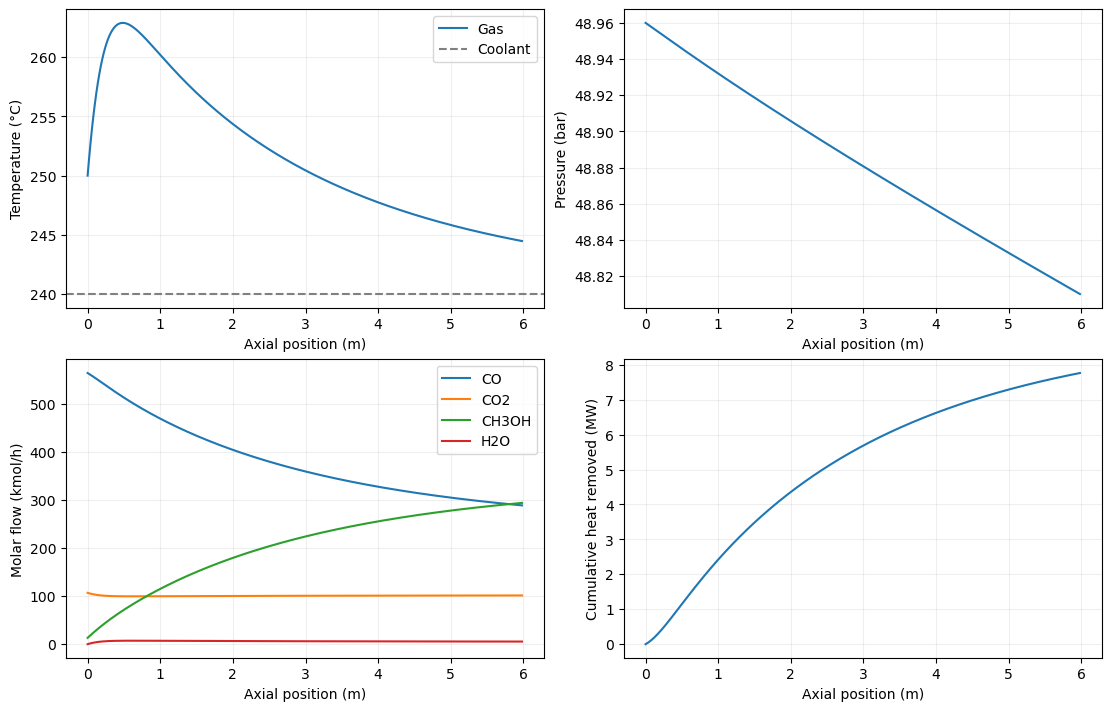

In [49]:
fig,axes=plt.subplots(2,2,figsize=(11,7),constrained_layout=True)
axes[0,0].plot(z,T-273.15,label='Gas');axes[0,0].axhline(coolant_temperature_C,color='grey',ls='--',label='Coolant');axes[0,0].set_ylabel('Temperature (°C)');axes[0,0].legend()
axes[0,1].plot(z,P/1e5);axes[0,1].set_ylabel('Pressure (bar)')
for s in ['CO','CO2','CH3OH','H2O']:axes[1,0].plot(z,F[idx[s]]*3.6,label=s)
axes[1,0].set_ylabel('Molar flow (kmol/h)');axes[1,0].legend()
axes[1,1].plot(z,Qc/1e6);axes[1,1].set_ylabel('Cumulative heat removed (MW)')
for ax in axes.flat:ax.set_xlabel('Axial position (m)');ax.grid(alpha=.2)
plt.show()
# The bed length and catalyst inventory are solved from the specified net methanol production target.